<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color='#BFD72F'>**Methodology** </font> <a class="anchor" id='top'></a> 

- [1. Introduction](#1) 
- [2. Import Libraries](#2) 
- [3. Create Metadata](#3)
- [4. Import Dataset](#4)  
- [5. Model and Assessment](#5) 
    - [5.1 Linear Regression](#5_1)
        - [5.1.1 Ordinary Least Squares (OLS)](#5_1_1)
        - [5.1.2 Ridge Regression](#5_1_2)
        - [5.1.3 Lasso Regression](#5_1_3)
        - [5.1.4 Elastic Net Regression](#5_1_4)
        - [5.1.5 Random Forest](#5_1_5)
    - [5.2 Model Comparison](#5_2)
    - [5.3 Test Models](#5_3)
- [6. Save the Results to Kaggle](#6) 
- [7. End of the Notebook](#7) 

<a class="anchor" id="1">

# **1. Introduction**

[Back to TOP](#TOP)
</a>

Here we will create models to predict the used car prices. We will create several models and later analyse their performances and choose the one that best predicts the target feature based on the MAE metric. The results here represent our final models with the thresholds and features defined in the "03_Feature_Selection" file that yield the best results we could.

<a class="anchor" id="2">

# **2. Import libraries**

[Back to TOP](#TOP)
</a>

The following libraries will help us develop the analyses and model for this project. Pandas and Numpy, provide the efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Finally, Scikit-learn offers a range of Machine Learning tools for model training, spliting the data and evaluate model performance. 

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import os


# Linear Regression - OLS, ridge, lasso, elastic net regression
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor


#Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Load Created Functions
from functions import *

# Set random seed for reproducibility
np.random.seed(40111) 

<a class="anchor" id="3">

# **3. Create Metadata**

[Back to TOP](#TOP)
</a>

Understanding the features helps interpret the data correctly and supports subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



<a class="anchor" id="4">

# **4. Import Dataset**

[Back to TOP](#top)
</a>

In this section, we load the preprocessed datasets that were previously saved after the data preprocessing steps. These datasets are ready for modelling and to get results.

In [2]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_feature_selected/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_final.csv", index_col=0)
X_val   = pd.read_csv(f"{data_path}X_val_final.csv", index_col=0)
test    = pd.read_csv(f"{data_path}test_final.csv", index_col=0)

# Load target variables and squeeze to convert DataFrame to Series since they have only one column
y_train = pd.read_csv(f"{data_path}y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv(f"{data_path}y_val.csv", index_col=0).squeeze()

<a class="anchor" id="5">

# **5. Model and Assessment**

[Back to TOP](#TOP)
</a>

In this notebook, we focus on training and evaluating different regression models to predict car resale prices. We start with a simple model to establish a baseline and progressively explore more complex models. The purpose of this notebook section is to create a structured workflow that allows us to train models efficiently, evaluate their performance, and compare predictions with actual values.

Before training any models, we define a helper function that simplifies the process. This function receives any scikit-learn regression model along with the training data (X_train and y_train) and returns the trained model. Using this function, we avoid repeating the same code for each model we want to test, making the workflow more modular and easier to maintain.

In [3]:
def train_model(model, X_train, y_train):
    """ Train the given model on provided data."""
    model.fit(X_train, y_train) # Fit the model
    return model

After training a regression model, it is important to assess its performance using multiple metrics. Now we define a function that calculates several commonly used regression metrics at once, providing a comprehensive overview of how well the model predicts the target feature.
This function can be applied to any trained regression model and any dataset, making it a flexible tool for model evaluation and comparison.

In [4]:
def evaluate_model(model, X, y):
    """Evaluate a regression model using multiple metrics:
    R2, Adjusted R2, MAE, MSE, RMSE, MedAE, MAPE."""
    n_samples = X.shape[0] # number of observations
    n_features = X.shape[1] # number of features
    
    y_pred = model.predict(X) # predicted values
    
    # Calculate metrics
    r2 = r2_score(y, y_pred)
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = rmse = np.sqrt(mse)
    medae = median_absolute_error(y, y_pred)
    mape = mean_absolute_percentage_error(y, y_pred)

# Compile metrics into a dictionary
    metrics_dict = {
        'R2': r2,
        'Adjusted R2': adj_r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MedAE': medae,
        'MAPE (%)': mape
    }
    return metrics_dict


<a class="anchor" id="5_1">

## **5.1** Linear Regression

[Back to TOP](#TOP)
</a>

Linear regression is a fundamental technique for predicting a continuous target feature based on input features. In this section, we apply different linear regression methods to the dataset and evaluate their performance. By comparing these approaches, we aim to understand how each method generalizes to unseen data and identify the most suitable model for predicting car resale prices.

<a class="anchor" id="5_1_1">

### **5.1.1** Ordinary Least Squares (OLS)
[Back to TOP](#TOP)
</a>

Ordinary Least Squares (OLS) is the standard form of linear regression. It estimates the coefficients of the model by minimizing the sum of the squared differences between the observed values and the values predicted by the model. OLS serves as a baseline model, providing a reference point for evaluating more complex or regularized regression methods. We will now implement this model.

In [5]:
# Train a Linear Regression model
lr_model = train_model(LinearRegression(), X_train, y_train)

# Predict on validation set
y_pred_val = lr_model.predict(X_val)

To better understand the model's performance, we create a table that compares the predicted values of the target feature with the actual values from the validation set. This gives a quick visual check of how close our predictions are to reality.

In [6]:
val_results = pd.DataFrame({'y_true': y_val.values.flatten(), 'y_pred': y_pred_val.flatten()}, 
                           index=y_val.index #ensures we can map the predictions to each observation correctly
                           )
val_results

,y_true,y_pred
carID,,
37025,18341,19177.805360
65090,8000,5328.718149
29197,12699,15950.169088
22100,16000,17143.938148
70417,17987,19212.639312
...,...,...
28050,14998,15733.070402
5533,40790,41002.682962
31127,3295,2752.119055


Now we evaluate the Linear Regression model on both the training and validation sets using our evaluation function. This allows us not only to measure how well the model predicts unseen data, but also to compare its performance on the training data, helping us identify potential overfitting or underfitting issues.

In [7]:
# Evaluate metrics for training and validation sets
metrics_train = evaluate_model(lr_model, X_train, y_train)
metrics_val = evaluate_model(lr_model, X_val, y_val)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': list(metrics_train.keys()),
    'Train': list(metrics_train.values()),
    'Validation': list(metrics_val.values())
})

# Round values for readability
comparison_df['Train'] = comparison_df['Train'].round(2)
comparison_df['Validation'] = comparison_df['Validation'].round(2)

# Display table
comparison_df

,Metric,Train,Validation
0,R2,0.81,0.81
1,Adjusted R2,0.81,0.81
2,MAE,2571.71,2602.83
3,MSE,17508494.37,18654859.97
4,RMSE,4184.32,4319.13
5,MedAE,1777.96,1778.79
6,MAPE (%),0.19,0.19


Now we will use statsmodels to analyze our Linear Regression model. This approach not only provides the coefficients, but also p-values and other statistics that allow us to assess the significance of each feature.

In [8]:
# Linear Regression Analysis with Statistical Significance
# Add intercept
X_sm = sm.add_constant(X_train)

# Fit OLS model
ols_model = sm.OLS(y_train, X_sm).fit()

# Display full statistical summary (includes coefficients, p-values, R², etc.)
print(ols_model.summary())




                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     4092.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:19:21   Log-Likelihood:            -5.9307e+05
No. Observations:               60778   AIC:                         1.186e+06
Df Residuals:                   60712   BIC:                         1.187e+06
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Since the overall model performance is not perfect, it can be more informative to analyze the coefficients separately. This allows us to identify which features have the strongest influence on the predictions and which contribute minimally, guiding potential feature selection.

In [9]:
# Extract model coefficients and align with feature names
coefs = pd.DataFrame(lr_model.coef_, index=X_train.columns, columns=['coefs'])

# Change to absolute values and sort by descending order for better interpretability
coefs['coefs'] = coefs['coefs'].abs()
coefs_sorted = coefs.sort_values('coefs', ascending=False)

coefs_sorted

,coefs
model_ RS6,11974.329101
model_ X5,8661.933005
model_ Q7,8635.994187
model_ SL CLASS,7250.406770
model_ Up,7102.917174
...,...
model_ Q3,738.494988
model_median_tax,562.453205
model_ Focus,497.778119
brand_median_mileage,297.554602


The analysis of the Linear Regression coefficients shows that certain features have a strong impact on the target, while others contribute minimally. The most influential features are model_RS6, model_X5, and model_Q7, indicating that both car models strongly affect predictions. Features with very small coefficients, such as brand_avg_age, brand_median_mileage and model_Focus, have minimal influence and could be candidates for removal in a feature selection process.

Overall, the model’s predictive power is mainly driven by model indicators. A wrapped feature selection approach could be applied iteratively to simplify the model without sacrificing performance. Visualizing the coefficients helps quickly identify the top and bottom contributors among all the features.

To better visualize the influence of each feature, we plot the top 10 and bottom 10 coefficients. This helps quickly identify the most and least impactful features in the model, making it easier to interpret the results conclude before and guide potential feature selection.

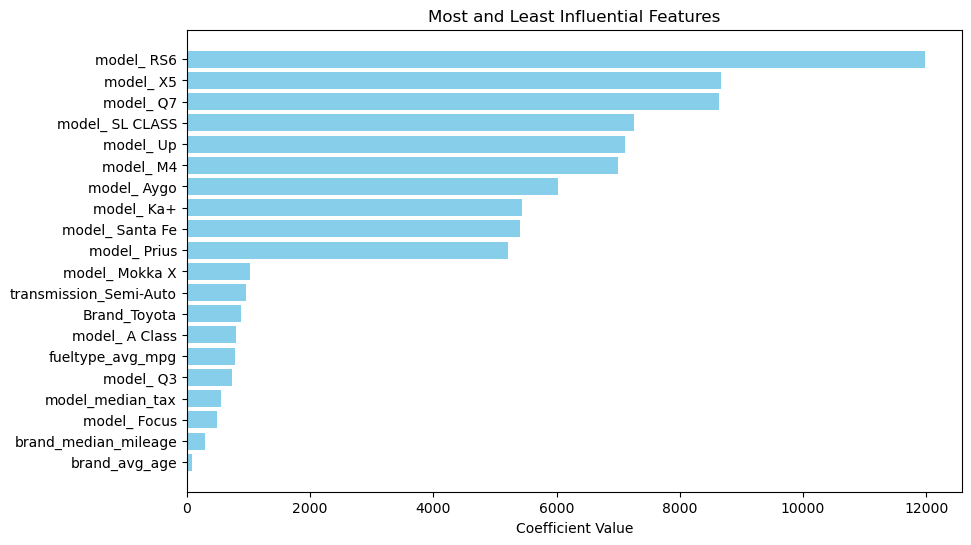

In [10]:
# Plot top 10 and bottom 10 features
top_bottom = pd.concat([coefs_sorted.head(10), coefs_sorted.tail(10)])

plt.figure(figsize=(10,6))
plt.barh(top_bottom.index, top_bottom['coefs'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Most and Least Influential Features')
plt.gca().invert_yaxis()  # largest coef on top
plt.show()

<a class="anchor" id="5_1_2">

### **5.1.2** Ridge Regression
[Back to TOP](#TOP)
</a>

Ridge Regression is a regularized version of Linear Regression that adds an L2 penalty on the coefficients. This helps prevent overfitting and can improve performance when features are correlated or highly feature. Ridge serves as a comparison to OLS, allowing us to evaluate the effect of L2 regularization. We will now implement this model.

In [11]:
# Create Ridge Regression model with fixed alpha
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_mean_absolute_error')

# Train the model
ridge_model = train_model(ridge_model, X_train, y_train)

# Evaluate on training and validation sets
train_metrics_ridge = evaluate_model(ridge_model, X_train, y_train)
val_metrics_ridge = evaluate_model(ridge_model, X_val, y_val)

# Display results
ridge_results = pd.DataFrame([train_metrics_ridge, val_metrics_ridge], index=['Train', 'Validation']).round(2).T
display(ridge_results)

,Train,Validation
R2,0.81,0.81
Adjusted R2,0.81,0.81
MAE,2571.71,2602.83
MSE,17508494.38,18654849.72
RMSE,4184.32,4319.13
MedAE,1777.97,1778.85
MAPE (%),0.19,0.19


<a class="anchor" id="5_1_3">

### **5.1.3** Lasso Regression
[Back to TOP](#TOP)
</a>

Lasso Regression is a linear regression method that adds an L1 penalty to the coefficients. This regularization can shrink some coefficients to zero, effectively performing feature selection and potentially simplifying the model. Lasso provides an alternative perspective to OLS and Ridge by emphasizing sparsity. We will now implement this model.

In [12]:
# Create Lasso Regression model with cross-validation (optimizing MAE)
lasso_model = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, random_state=42)

# Train the model
lasso_model = train_model(lasso_model, X_train, y_train)

# Evaluate on training and validation sets
train_metrics_lasso = evaluate_model(lasso_model, X_train, y_train)
val_metrics_lasso = evaluate_model(lasso_model, X_val, y_val)

# Display results
lasso_results = pd.DataFrame([train_metrics_lasso, val_metrics_lasso], index=['Train', 'Validation']).round(2).T
display(lasso_results)


,Train,Validation
R2,0.81,0.81
Adjusted R2,0.81,0.81
MAE,2571.66,2602.77
MSE,17508505.06,18654665.68
RMSE,4184.32,4319.10
MedAE,1776.94,1779.66
MAPE (%),0.19,0.19


<a class="anchor" id="5_1_4">

### **5.1.4** Elastic Net Regression
[Back to TOP](#TOP)
</a>

This technique combines both L1 and L2 penalties, balancing the effects of Lasso and Ridge regularization. This approach can be particularly useful when features are highly correlated or when both shrinkage and sparsity are desirable. Elastic Net allows us to explore how combined regularization impacts model performance. We will now implement this model.

In [13]:
# Create Elastic Net Regression model with cross-validation (optimizing MAE)
elastic_model = ElasticNetCV(
    alphas=np.logspace(-3, 3, 50),
    l1_ratio=np.linspace(0.1, 0.9, 9),
    cv=5,
    random_state=42
)

# Train the model
elastic_model = train_model(elastic_model, X_train, y_train)

# Evaluate on training and validation sets
train_metrics_elastic = evaluate_model(elastic_model, X_train, y_train)
val_metrics_elastic = evaluate_model(elastic_model, X_val, y_val)

# Display results
elastic_results = pd.DataFrame([train_metrics_elastic, val_metrics_elastic], index=['Train', 'Validation']).round(2).T
display(elastic_results)


,Train,Validation
R2,0.81,0.81
Adjusted R2,0.81,0.81
MAE,2571.99,2603.20
MSE,17511842.01,18649901.36
RMSE,4184.72,4318.55
MedAE,1776.12,1783.12
MAPE (%),0.19,0.19


<a class="anchor" id="5_1_5">

### **5.1.5** Random Forest
[Back to TOP](#TOP)
</a>

Random Forest is based on combining multiple decision trees. Each tree is trained on a random subset of the data and features, and the final prediction is obtained by aggregating the outputs of all trees (using average for regression). This approach reduces variance, increases robustness, and helps prevent overfitting compared to a single decision tree. We will now implement this model.

In [14]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,        # number of trees in the forest
    max_depth=None,          # let trees expand fully
    random_state=42,
    n_jobs=-1                # use all cores for faster training
)

# Train the model
rf_model = train_model(rf_model, X_train, y_train)

# Evaluate on training and validation sets
train_metrics_rf = evaluate_model(rf_model, X_train, y_train)
val_metrics_rf = evaluate_model(rf_model, X_val, y_val)

# Display results
rf_results = pd.DataFrame(
    [train_metrics_rf, val_metrics_rf],
    index=['Train', 'Validation']
).round(2).T

display(rf_results)

,Train,Validation
R2,0.99,0.94
Adjusted R2,0.99,0.94
MAE,534.18,1428.15
MSE,914150.48,6113047.90
RMSE,956.11,2472.46
MedAE,319.14,859.55
MAPE (%),0.03,0.09


<a class="anchor" id="5_2">

## **5.2** Model Comparison

[Back to TOP](#TOP)
</a>

After training and evaluating each regression model individually, we now compare their performance using key metrics. This comparison allows us to understand which model generalizes best to unseen data and whether regularization techniques offer improvements over standard Linear Regression.
By analyzing these metrics side by side, we can identify the most reliable model for predicting car resale prices and make informed decisions about potential adjustments or further tuning.

In [15]:
# List of models and their trained instances
models = {
    'OLS': lr_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model,
    'Elastic Net': elastic_model,
    'Random Forest': rf_model
}

#Evaluate each model on the validation set and store results
results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, X_val, y_val)

# Convert the results dictionary into a DataFrame
# Metrics as rows, models as columns
metrics_df = pd.DataFrame(results)

# Display the metrics
metrics_df.round(2)

,OLS,Ridge,Lasso,Elastic Net,Random Forest
R2,0.81,0.81,0.81,0.81,0.94
Adjusted R2,0.81,0.81,0.81,0.81,0.94
MAE,2602.83,2602.83,2602.77,2603.20,1428.15
MSE,18654859.97,18654849.72,18654665.68,18649901.36,6113047.90
RMSE,4319.13,4319.13,4319.10,4318.55,2472.46
MedAE,1778.79,1778.85,1779.66,1783.12,859.55
MAPE (%),0.19,0.19,0.19,0.19,0.09


We compared five regression models, OLS, Ridge, Lasso, Elastic Net, and Random Forest, on both training and validation datasets. From this comparison, we observe that OLS, Ridge, and Lasso all perform very similarly, explaining approximately **81% of the variance (R² ≈ 0.81)** with nearly identical MAE and RMSE values. These consistent errors indicate that all three models generalize well to unseen data, showing **no signs of overfitting**.

Regularization (Ridge and Lasso) does not provide noticeable improvement over OLS, which suggests that multicollinearity and irrelevant features are not major issues at this stage of the project.

Elastic Net regression shows slightly lower performance, which is likely due to its use of both L1 and L2 regularization without optimized hyperparameters. To improve Elastic Net results, **tuning alpha and l1_ratio would be necessary**.

In contrast, the **Random Forest model outperforms all linear models, achieving a much higher R² (0.94)** and significantly lower prediction errors (MAE, RMSE, MedAE). This indicates that the nonlinear relationships in the dataset are better captured by an ensemble tree-based model.

Overall, OLS remains a strong interpretable baseline, while **Random Forest currently delivers the best predictive performance**.

<a class="anchor" id="5_3">

## **5.3** Test Models

[Back to TOP](#TOP)
</a>

In [16]:
# Predict using all models on the test set
test_predictions = {
    'OLS': lr_model.predict(test),
    'Ridge': ridge_model.predict(test),
    'Lasso': lasso_model.predict(test),
    'Elastic Net': elastic_model.predict(test),
    'Random Forest': rf_model.predict(test)
}

# Convert to a DataFrame for easy comparison
test_predictions_df = pd.DataFrame(test_predictions, index=test.index)

# Show the first few predictions
test_predictions_df.head(10)

,OLS,Ridge,Lasso,Elastic Net,Random Forest
carID,,,,,
89856,15675.309931,15675.431883,15681.276327,15741.812970,15633.820
106581,23491.272504,23491.280788,23488.566020,23479.828674,25231.115
80886,11758.446644,11758.423772,11760.503114,11769.625994,14069.645
100174,16217.376405,16217.418122,16215.760666,16201.245897,16756.615
81376,27754.103248,27754.171223,27755.529933,27793.555946,26671.225
85391,9321.146831,9321.155783,9321.098271,9317.663725,10134.835
82175,14544.465553,14544.421450,14544.864581,14571.427507,14450.230
95250,14882.576266,14882.615057,14887.608349,14927.481371,15360.355
85071,2913.809701,2913.689818,2913.582678,2912.563452,5206.325


In [17]:
test_predictions

{'OLS': array([15675.30993131, 23491.27250402, 11758.44664405, ...,
        34957.21829907, 20329.126581  , 11727.91362101]),
 'Ridge': array([15675.43188322, 23491.28078779, 11758.42377235, ...,
        34957.23190254, 20329.1853222 , 11727.92223941]),
 'Lasso': array([15681.27632663, 23488.5660196 , 11760.50311385, ...,
        34953.73288649, 20331.51321056, 11728.70557603]),
 'Elastic Net': array([15741.81297017, 23479.82867433, 11769.62599362, ...,
        34912.1102595 , 20340.53958088, 11738.45922989]),
 'Random Forest': array([15633.82 , 25231.115, 14069.645, ..., 34566.01 , 21085.345,
        10998.05 ])}

<a class="anchor" id="6">

# **6. Save results to Kaggle**

[Back to TOP](#TOP)
</a>

In [18]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../results/kaggle_submissions/"
os.makedirs(selected_dir, exist_ok=True)

In [19]:
best_model_name = metrics_df.loc['MAE'].idxmin()  # gets the column (model) with lowest MAE
best_mae_value = metrics_df.loc['MAE', best_model_name]

print(f"Best model based on MAE: {best_model_name} (MAE = {best_mae_value:.2f})")

Best model based on MAE: Random Forest (MAE = 1428.15)


In [20]:
# Extract carID
car_ids = test.index.values

# Create DataFrame with best model predictions
best_model_df = pd.DataFrame({
    'carID': car_ids,
    'price': test_predictions[best_model_name]
})

# Save predictions to CSV
best_model_df.to_csv(f"{selected_dir}/{best_model_name.lower().replace(' ', '_')}_predictions.csv", index=False)


<a class="anchor" id="7">

# **7. End of the Notebook**

[Back to TOP](#TOP)
</a>

From the modeling and assessment stage, we developed and evaluated several predictive models to estimate car prices based on the processed features. Different algorithms were trained, and their performance was compared using appropriate evaluation metrics to identify the most effective approach. The analysis of results provided valuable insights into the model’s predictive capabilities, highlighting strengths, limitations, and potential areas for improvement. This stage represents a crucial step in validating the overall workflow and ensuring that the final model delivers accurate and reliable predictions..